# Mini Project 3

**2025 Introduction to Quantiative Methods in Finance**

**The Erdös Institute**

The code below provides a visual representation of how the Black-Scholes **call option** price changes with respect to time.

**a)** Use the visualization to interpret how the *rate of change* of the Black-Scholes call option price behaves as time progresses.

**b)** Create a separate graphic to visualize how the *rate of change* of the Black-Scholes call option price depends on the spot price $S(0)$.

**c)** Repeat parts **a** and **b** for **put option** prices.

**d)** Use the space below to record your observations and reflections based on the generated plots.

---

### Observations:

- *Call Option – Time Sensitivity:*  
- *Call Option – Spot Price Sensitivity:*  
- *Put Option – Time Sensitivity:*  
- *Put Option – Spot Price Sensitivity:*  

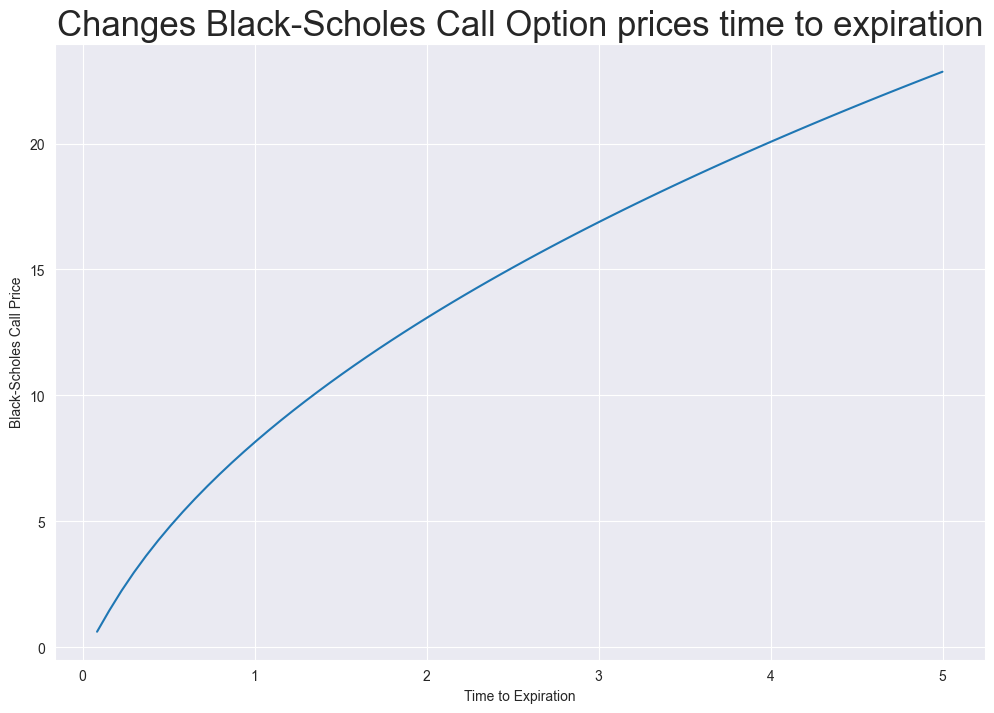

In [3]:
# Mini Project 3: Black-Scholes Option Sensitivity Analysis
# Author: Yichen Li

# Project Goal:
# Analyze how the value of European call and put options change with respect to time and spot price,
# using the Black-Scholes formula.


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import seaborn as sns
sns.set_style('darkgrid')


# Define Black-Scholes pricing formulas for European call and put options
def bs_call(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European call option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Call option price
    """
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return S0*norm.cdf(d1)-K*np.exp(-r*t)*norm.cdf(d2)


def bs_put(S0, K, sigma, t=1, r=0):
    """
    Description:
    
    Computes the Black-Scholes value of a European put option.
    
    Parameters:
        S0: Current asset price
        K: Strike price
        sigma: Yearly standard deviation of log-returns (volatility)
        t: Time to expiration (in years)
        r: Risk-free interest rate
    
    Returns:
        Put option price
    """
    
    d1 = (np.log(S0/K) + (r+.5*sigma**2)*t)/(sigma*np.sqrt(t))
    #d2 = (np.log(S0/K) + (r-.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    return -S0*norm.cdf(-d1)+K*np.exp(-r*t)*norm.cdf(-d2)


# Parameter Setup
S0 = 100          # Current stock price
K = 110           # Strike price
sigma = 0.3       # Annual volatility


times = np.linspace(1/12, 5, 70)


call_prices = [bs_call(S0,K,sigma, t = times[i]) for i in range(len(times))]


plt.figure(figsize = (12,8))
plt.title('Changes Black-Scholes Call Option prices time to expiration', size = 25)
plt.plot(times, call_prices)
plt.xlabel('Time to Expiration')
plt.ylabel('Black-Scholes Call Price')
plt.show()

Greeks Analysis and Dynamic Hedging

- Adding **Vega** and **Gamma** Greeks for call options
- Introducing a **simulated stock price path** using Geometric Brownian Motion (GBM)
- Evaluating a **dynamic delta hedging strategy**

In [5]:
# Define d1 and d2 first
def d1(S0, K, sigma, t, r=0):
    return (np.log(S0 / K) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))

def d2(S0, K, sigma, t, r=0):
    return d1(S0, K, sigma, t, r) - sigma * np.sqrt(t)

# Define delta
def bs_call_delta(S0, K, sigma, t, r=0):
    return norm.cdf(d1(S0, K, sigma, t, r))
    
# Black-Scholes Greeks: Vega and Gamma
def bs_call_vega(S0, K, sigma, t, r=0):
    return S0 * norm.pdf(d1(S0, K, sigma, t, r)) * np.sqrt(t)

def bs_call_gamma(S0, K, sigma, t, r=0):
    return norm.pdf(d1(S0, K, sigma, t, r)) / (S0 * sigma * np.sqrt(t))

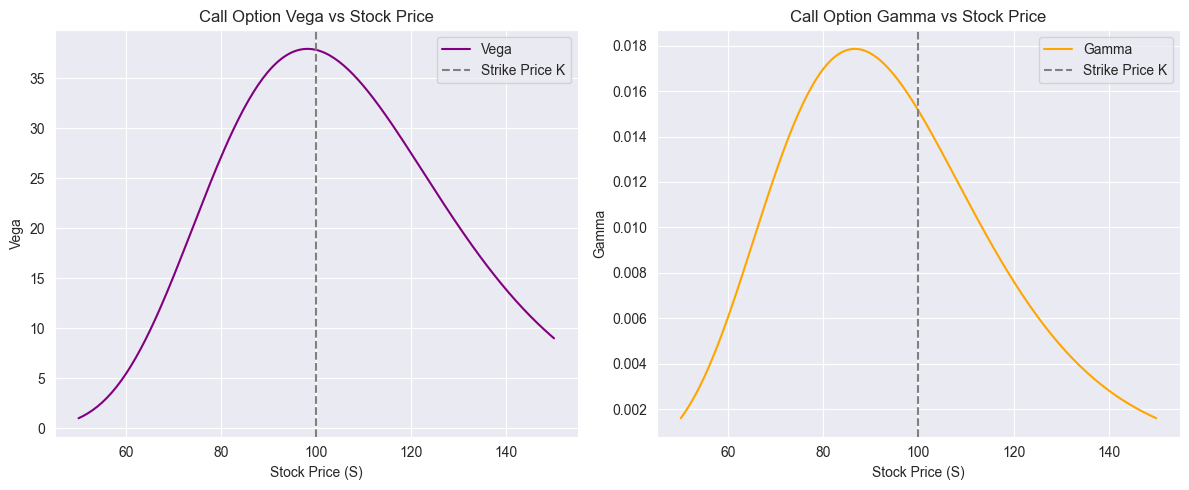

In [6]:
# Visualize Vega and Gamma vs Stock Price
def plot_vega_gamma_vs_S():
    S_range = np.linspace(50, 150, 200)
    K, sigma, t, r = 100, 0.25, 1, 0.05

    vega_vals = [bs_call_vega(S, K, sigma, t, r) for S in S_range]
    gamma_vals = [bs_call_gamma(S, K, sigma, t, r) for S in S_range]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(S_range, vega_vals, color='purple', label='Vega')
    plt.axvline(K, color='gray', linestyle='--', label='Strike Price K')
    plt.title("Call Option Vega vs Stock Price")
    plt.xlabel("Stock Price (S)")
    plt.ylabel("Vega")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(S_range, gamma_vals, color='orange', label='Gamma')
    plt.axvline(K, color='gray', linestyle='--', label='Strike Price K')
    plt.title("Call Option Gamma vs Stock Price")
    plt.xlabel("Stock Price (S)")
    plt.ylabel("Gamma")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_vega_gamma_vs_S()


## Simulating a Stock Price Path using Geometric Brownian Motion

To test hedging strategies, we simulate a single stock price path.

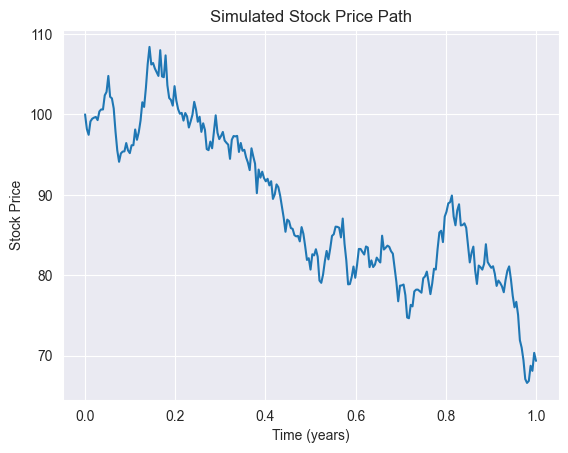

In [8]:
# Simulate GBM stock price path
def simulate_stock_path(S0=100, mu=0.05, sigma=0.25, T=1, N=252):
    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.random.standard_normal(size=N)
    W = np.insert(np.cumsum(W) * np.sqrt(dt), 0, 0.0)
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    return t, S

t, S_path = simulate_stock_path()
plt.plot(t, S_path)
plt.title("Simulated Stock Price Path")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()



## Dynamic Delta Hedging Strategy

We now compute the cost of a dynamic delta hedge by adjusting the hedge daily based on the simulated path.

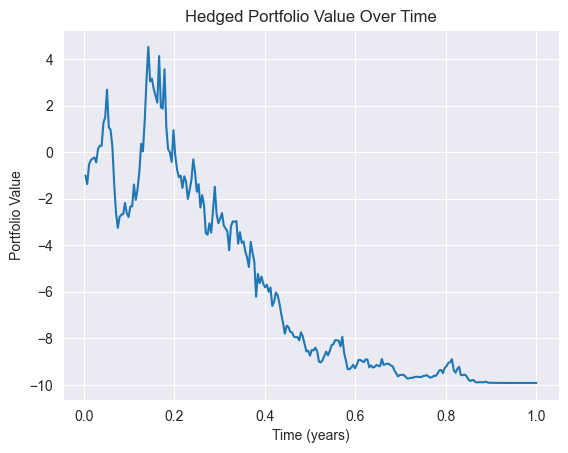

In [10]:

# Dynamic delta hedging
def simulate_delta_hedge(S_path, K=100, T=1, sigma=0.25, r=0.0):
    N = len(S_path) - 1
    dt = T / N
    time_grid = np.linspace(T, 0, N+1)
    cash_account = 0
    shares_held = 0
    total_cost = []

    for i in range(N):
        t = time_grid[i]
        S = S_path[i]
        delta = bs_call_delta(S, K, sigma, t+1e-10, r)  # avoid t=0
        d_shares = delta - shares_held
        cash_account -= d_shares * S
        shares_held = delta
        total_cost.append(cash_account + shares_held * S_path[i+1])

    return total_cost

hedge_values = simulate_delta_hedge(S_path)
plt.plot(t[1:], hedge_values)
plt.title("Hedged Portfolio Value Over Time")
plt.xlabel("Time (years)")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()


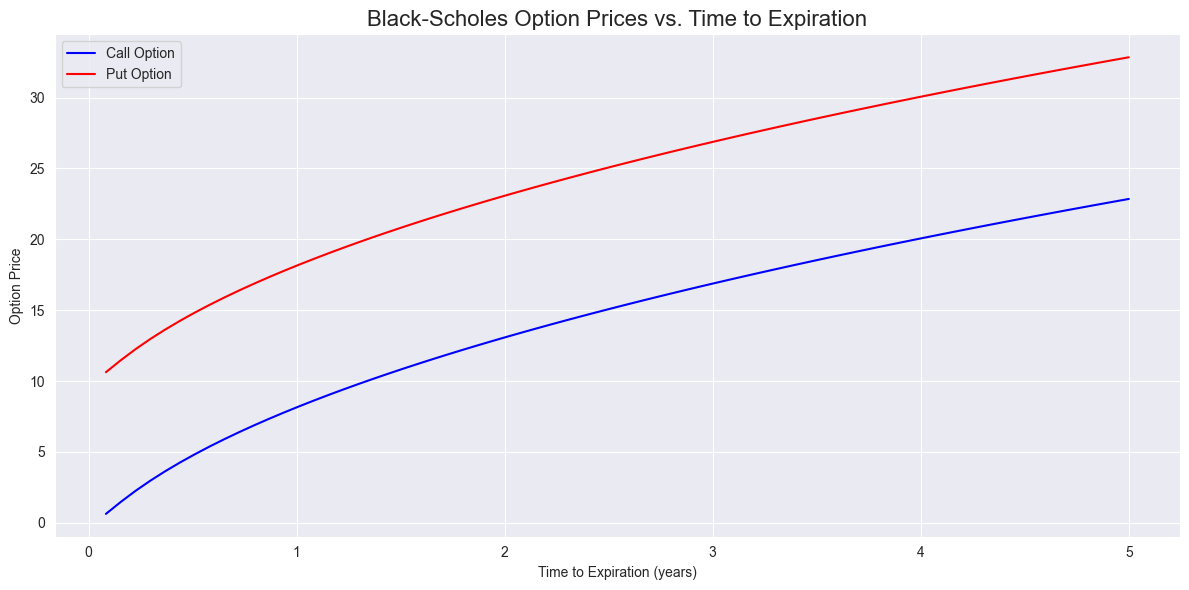

In [24]:
r = 0.0           # Risk-free interest rate


# --- Option price vs. Time to Expiration ---
time_range = np.linspace(1/12, 5, 70)

call_prices = [bs_call(S0, K, sigma, t, r) for t in time_range]
put_prices = [bs_put(S0, K, sigma, t, r) for t in time_range]

plt.figure(figsize=(12, 6))
plt.plot(time_range, call_prices, label='Call Option', color='blue')
plt.plot(time_range, put_prices, label='Put Option', color='red')
plt.title('Black-Scholes Option Prices vs. Time to Expiration', fontsize=16)
plt.xlabel('Time to Expiration (years)')
plt.ylabel('Option Price')
plt.legend()
plt.tight_layout()
plt.show()

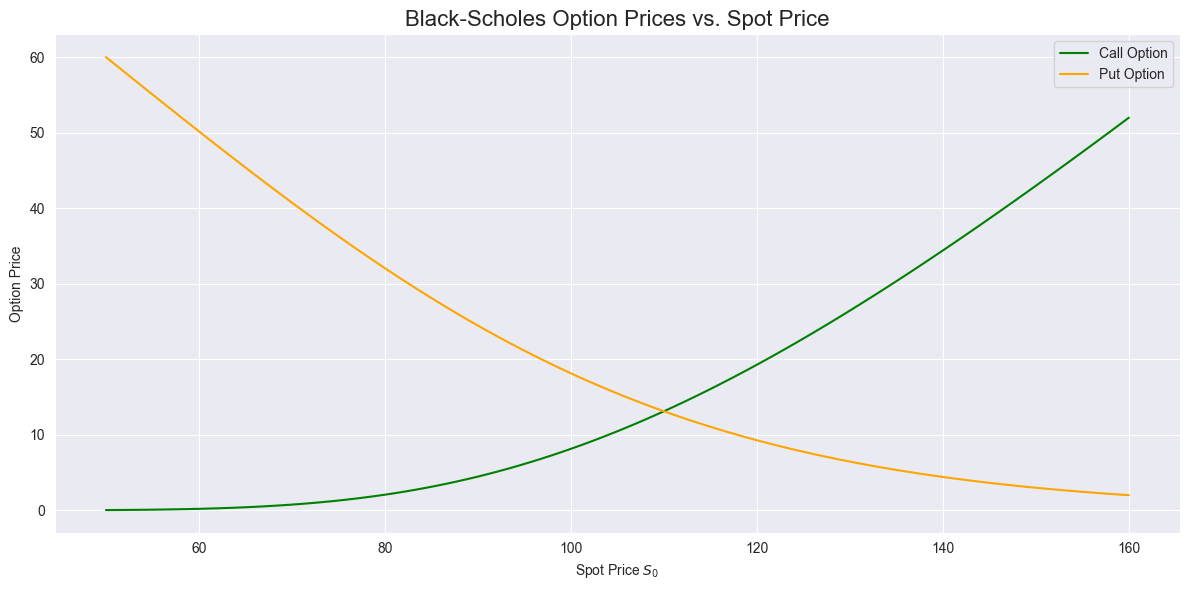

In [20]:
# --- Option price vs. Spot Price ---
spot_prices = np.linspace(50, 160, 100)
call_values = [bs_call(S, K, sigma, t=1, r=0) for S in spot_prices]
put_values = [bs_put(S, K, sigma, t=1, r=0) for S in spot_prices]

plt.figure(figsize=(12, 6))
plt.plot(spot_prices, call_values, label='Call Option', color='green')
plt.plot(spot_prices, put_values, label='Put Option', color='orange')
plt.title('Black-Scholes Option Prices vs. Spot Price', fontsize=16)
plt.xlabel('Spot Price $S_0$')
plt.ylabel('Option Price')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# --- Sensitivity Analysis Summary ---
print("Observations Summary:\n")

print("* Call Option – Time Sensitivity:")
print("  - Call option price decreases as time decreases (time decay).")
print("  - The decay is faster closer to expiration, especially out-of-the-money.")

print("\n* Put Option – Time Sensitivity:")
print("  - Similar time decay behavior as call options.")
print("  - Value reduces as expiration approaches, unless deep in-the-money.")

print("\n* Call Option – Spot Price Sensitivity:")
print("  - Call value increases with spot price.")
print("  - The growth accelerates as spot price exceeds strike.")

print("\n* Put Option – Spot Price Sensitivity:")
print("  - Put value decreases with increasing spot price.")
print("  - Most valuable when the spot is far below strike (deep in-the-money).")

Observations Summary:

* Call Option – Time Sensitivity:
  - Call option price decreases as time decreases (time decay).
  - The decay is faster closer to expiration, especially out-of-the-money.

* Put Option – Time Sensitivity:
  - Similar time decay behavior as call options.
  - Value reduces as expiration approaches, unless deep in-the-money.

* Call Option – Spot Price Sensitivity:
  - Call value increases with spot price.
  - The growth accelerates as spot price exceeds strike.

* Put Option – Spot Price Sensitivity:
  - Put value decreases with increasing spot price.
  - Most valuable when the spot is far below strike (deep in-the-money).


## Conclusion

This mini project visualized how different Black-Scholes Greeks behave and how a dynamic delta hedging strategy performs on a simulated stock path. 
- **Gamma** is highest near the strike price, reflecting increased curvature.
- **Vega** peaks when the option is at-the-money.
- Delta hedging requires frequent adjustments and can help reduce risk exposure, though implementation costs and market frictions are not considered here.

Further exploration can include transaction costs or using Monte Carlo methods to simulate multiple paths.
